In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This block imports necessary libraries like `google.colab` for Colab-specific functionalities (like mounting Google Drive), `os` for interacting with the operating system, `pandas` for data manipulation, `matplotlib.pyplot` for plotting, and `torch` and `torch.nn` for building neural networks. It also imports `Dataset` and `DataLoader` for handling data, and `sklearn.metrics` for evaluating model performance.

In [ ]:
#path_nsr = '/content/drive/MyDrive/ALS Heart Rate Data/NSR Processed/RR Intervals/'
path_nsr = '/content/drive/MyDrive/ALS Heart Rate Data/NSR Processed/RR Intervals' #<----- Erick's file path
#path_hrv = '/content/drive/MyDrive/ALS Heart Rate Data/HRV Timeseries Data (Healthy Patients)' Take out for now

This cell defines the file path to the directory containing the RR interval data files in Google Drive. This is where the model will load its training data from.

Load RR files and Patient info into one dataframe
First 1000 rr intervals


In [ ]:
all_dfs = []

RR_MIN = 300
RR_MAX = 2000

for fname in os.listdir(path_nsr):
    if fname.endswith('.txt'):
        fpath = os.path.join(path_nsr, fname)
        rr_values = []
        with open(fpath, 'r') as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        val = float(line)
                        if RR_MIN <= val <= RR_MAX:
                            rr_values.append(val)
                    except:
                        continue
                if len(rr_values) == 1000:
                    break

        df = pd.DataFrame({'RR_interval_ms': rr_values, 'File': fname})
        all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)
final_df = final_df[~final_df['File'].str.contains('24')].reset_index(drop=True)

print(f"Total rows loaded: {len(final_df)}")
print(f"Unique patients: {final_df['File'].nunique()}")
print(final_df.head())

Total rows loaded: 53000
Unique patients: 53
   RR_interval_ms           File
0           695.0  nsr001_rr.txt
1           710.0  nsr001_rr.txt
2           710.0  nsr001_rr.txt
3           703.0  nsr001_rr.txt
4           710.0  nsr001_rr.txt


This block reads all `.txt` files from the specified `path_nsr` directory. It extracts RR interval values from each file, filters them to be within a `RR_MIN` (300ms) and `RR_MAX` (2000ms) range, and limits to the first 1000 valid intervals per file. These intervals are then compiled into a single Pandas DataFrame. It also removes any files containing '24' in their name.

Data cleaning : Clean data
Converts the RR column from text to numbers, then drops any rows that couldn't be converted.

In [ ]:
print(final_df['RR_interval_ms'].dtype)
print(final_df['RR_interval_ms'].unique()[:20])

final_df['RR_interval_ms'] = pd.to_numeric(final_df['RR_interval_ms'], errors='coerce')

before = len(final_df)
final_df = final_df.dropna(subset=['RR_interval_ms']).reset_index(drop=True)
after = len(final_df)

print(f"Removed {before - after} bad rows")
print(f"Clean rows remaining: {after}")
print(final_df['RR_interval_ms'].dtype)

float64
[695. 710. 703. 679. 664. 687. 656. 671. 726. 718. 734. 750. 640. 648.
 632. 757. 742. 617. 625. 773.]
Removed 0 bad rows
Clean rows remaining: 53000
float64


This cell ensures that the 'RR_interval_ms' column in the DataFrame is of a numeric type. It attempts to convert values to numbers, coercing any non-numeric values into `NaN` (Not a Number). Then, it removes any rows that ended up with `NaN` in this column, effectively cleaning out bad data entries.

Defining a window size of 50 to learn

In [ ]:
WINDOW_SIZE = 50

def make_windows(rr_series, window=WINDOW_SIZE):
    X, y = [], []
    for i in range(len(rr_series) - window):
        X.append(rr_series[i : i + window])
        y.append(rr_series[i + window])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

This function `make_windows` takes a series of RR intervals and creates input-output pairs for the neural network. For each window of `WINDOW_SIZE` (which is 50), it uses the previous 50 RR intervals to predict the next RR interval. `X` will contain the input sequences, and `y` will contain the target predictions.

Running window on all the patients and checking if they have enough data

In [ ]:
import numpy as np
windows_per_patient = {}

for pid in final_df['File'].unique():
    rr = final_df[final_df['File'] == pid]['RR_interval_ms'].values[:1000]
    if len(rr) > WINDOW_SIZE:
        X, y = make_windows(rr)
        windows_per_patient[pid] = (X, y)

print(f"Patients with enough data: {len(windows_per_patient)}")

sample_pid = list(windows_per_patient.keys())[0]
X_ex, y_ex = windows_per_patient[sample_pid]
print(f"Patient {sample_pid} → X shape: {X_ex.shape}, y shape: {y_ex.shape}")

Patients with enough data: 53
Patient nsr001_rr.txt → X shape: (950, 50), y shape: (950,)


This code iterates through each unique patient in the `final_df`. For each patient, it extracts their RR intervals and applies the `make_windows` function to create `X` (input windows) and `y` (target values). These windowed datasets are stored in the `windows_per_patient` dictionary, ensuring only patients with enough data to form at least one window are included.

Initializing a list to store metrics, and prepares list of patients for the
patient validation

In [ ]:
all_results = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

patient_ids = list(windows_per_patient.keys())

Using device: cuda


This cell initializes an empty list `all_results` to store evaluation metrics. It also checks if a GPU (CUDA) is available and sets the `device` variable accordingly for PyTorch operations, which significantly speeds up training. Finally, it creates a list of unique patient IDs that will be used for cross-validation.

Data Validation of leaving one patient out. Every other patient becomes training data

In [ ]:
for val_patient in patient_ids:
    print(f"\nRunning held-out patient: {val_patient}")
#val_patient = list(windows_per_patient.keys())[0]

    X_train_list, y_train_list = [], []

    for pid, (X, y) in windows_per_patient.items():
        if pid != val_patient:
           X_train_list.append(X)
           y_train_list.append(y)

    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)

    X_val, y_val = windows_per_patient[val_patient]

    print(f"Held-out patient: {val_patient}")
    print(f"X_train shape: {X_train.shape}")
    print(f"X_val shape:   {X_val.shape}")


Running held-out patient: nsr001_rr.txt
Held-out patient: nsr001_rr.txt
X_train shape: (49400, 50)
X_val shape:   (950, 50)

Running held-out patient: nsr003_rr.txt
Held-out patient: nsr003_rr.txt
X_train shape: (49400, 50)
X_val shape:   (950, 50)

Running held-out patient: nsr002_rr.txt
Held-out patient: nsr002_rr.txt
X_train shape: (49400, 50)
X_val shape:   (950, 50)

Running held-out patient: nsr010_rr.txt
Held-out patient: nsr010_rr.txt
X_train shape: (49400, 50)
X_val shape:   (950, 50)

Running held-out patient: nsr007_rr.txt
Held-out patient: nsr007_rr.txt
X_train shape: (49400, 50)
X_val shape:   (950, 50)

Running held-out patient: nsr005_rr.txt
Held-out patient: nsr005_rr.txt
X_train shape: (49400, 50)
X_val shape:   (950, 50)

Running held-out patient: nsr004_rr.txt
Held-out patient: nsr004_rr.txt
X_train shape: (49400, 50)
X_val shape:   (950, 50)

Running held-out patient: nsr011_rr.txt
Held-out patient: nsr011_rr.txt
X_train shape: (49400, 50)
X_val shape:   (950, 50)


This block sets up a Leave-One-Out Cross-Validation (LOOCV) loop. For each patient, it designates that patient's data as the validation set and uses all other patients' data as the training set. It then prints the shapes of the training and validation sets for each iteration to confirm the split.

SubSampling to make training faster

In [ ]:
MAX_TRAIN_WINDOWS = 200_000

rng = np.random.default_rng(seed=42)
idx = rng.choice(len(X_train), size=min(MAX_TRAIN_WINDOWS, len(X_train)), replace=False)

X_train = X_train[idx]
y_train = y_train[idx]

print(f"X_train shape after subsample: {X_train.shape}")
print(f"y_train shape after subsample: {y_train.shape}")

X_train shape after subsample: (49400, 50)
y_train shape after subsample: (49400,)


To manage training time and prevent excessive computation, this cell subsamples the training data. If the number of training windows exceeds `MAX_TRAIN_WINDOWS` (200,000), it randomly selects a subset of that size. This helps to make training more efficient without using the entire dataset, which can be very large.

Setting the standards and normalizing the data so we can train faster

In [ ]:
rr_mean = X_train.mean()
rr_std  = X_train.std() + 1e-8

X_train_scaled = (X_train - rr_mean) / rr_std
X_val_scaled   = (X_val   - rr_mean) / rr_std

y_mean = rr_mean
y_std  = rr_std
y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled   = (y_val   - y_mean) / y_std

print(f"y_train mean: {y_mean:.1f} ms, std: {y_std:.1f} ms")
print(f"X_train_scaled mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")
print(f"X_val_scaled   mean: {X_val_scaled.mean():.4f},  std: {X_val_scaled.std():.4f}")

y_train mean: 736.4 ms, std: 129.0 ms
X_train_scaled mean: 0.0000, std: 1.0000
X_val_scaled   mean: -1.0311,  std: 0.2966


This cell performs standardization on the training and validation data. It calculates the mean (`rr_mean`) and standard deviation (`rr_std`) from the *training* data and then uses these values to normalize both the training and validation inputs (`X`) and outputs (`y`). Standardization helps neural networks train more effectively by ensuring input features have a mean of zero and a standard deviation of one.

Defining the CNN Model

In [ ]:
import torch
import torch.nn as nn

class RR_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(8),
            nn.Flatten(),

            nn.Linear(128 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x.unsqueeze(1)).squeeze(1)

model = RR_CNN()
print(model)
total = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total:,}")


RR_CNN(
  (net): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=8)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=1024, out_features=128, bias=True)
    (14): ReLU()
    (15): Dropout(p=0.3, inplace=False)
    (16): Linear(in_features=128, out_features=1, bias=True)
  )
)

Tota

This code defines the Convolutional Neural Network (CNN) model architecture (`RR_CNN`). It consists of convolutional layers, batch normalization, ReLU activation, max pooling, an adaptive average pooling layer, a flatten layer, and linear layers with dropout. The `forward` method defines how data flows through these layers. It also prints a summary of the model structure and the total number of trainable parameters.

Data Loading the dataset and classes into batches

In [ ]:
from torch.utils.data import Dataset, DataLoader

class RRWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = RRWindowDataset(X_train_scaled, y_train_scaled)
val_dataset   = RRWindowDataset(X_val_scaled,   y_val_scaled)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Train batches: 193
Val batches:   4


This block defines a custom PyTorch `Dataset` class called `RRWindowDataset` to easily handle the windowed RR interval data. It also creates `DataLoader` instances for both the scaled training and validation datasets. DataLoaders are crucial for efficiently feeding data to the model in batches during training.

Setup for traning Checking CPU/GPU for training time, Setting up the MSE

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = RR_CNN().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 6
train_losses = []
val_losses = []

Using device: cuda


This cell sets up the training environment. It ensures the model runs on the available GPU if present (`device`), initializes a new instance of the `RR_CNN` model, defines the Mean Squared Error (`MSELoss`) as the loss function, and sets up the Adam optimizer for updating model weights. It also sets the number of training epochs to 6 and initializes lists to track training and validation losses.

Model training: Prints train and val loss after each epoch so you can watch the model improve

In [ ]:
for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            running_val_loss += loss.item() * X_batch.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")

Epoch 1 | Train Loss: 0.116812 | Val Loss: 0.028527
Epoch 2 | Train Loss: 0.091938 | Val Loss: 0.027586
Epoch 3 | Train Loss: 0.084324 | Val Loss: 0.024158
Epoch 4 | Train Loss: 0.080994 | Val Loss: 0.025588
Epoch 5 | Train Loss: 0.080330 | Val Loss: 0.028393
Epoch 6 | Train Loss: 0.078781 | Val Loss: 0.033691


This is the main training loop. For each epoch, it:  
1. Sets the model to training mode (`model.train()`).  
2. Iterates through batches from the `train_loader`, moves data to the device (GPU), performs a forward pass, calculates the loss, performs backpropagation, and updates model weights.  
3. Calculates the average training loss for the epoch.  
4. Sets the model to evaluation mode (`model.eval()`).  
5. Iterates through batches from the `val_loader` (without gradient calculations), performs a forward pass, calculates the loss, and calculates the average validation loss.  
6. Prints the training and validation loss for the current epoch.

Evaluate the model on the left out patient

In [ ]:
model.eval()

with torch.no_grad():
    X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
    y_val_pred_scaled = model(X_val_tensor).cpu().numpy()

y_val_pred = y_val_pred_scaled * y_std + y_mean
y_val_true = y_val_scaled      * y_std + y_mean

print(f"Sample predictions: {y_val_pred[:5].flatten()}")
print(f"Sample actuals:     {y_val_true[:5]}")

Sample predictions: [605.39954 590.4542  585.107   574.6482  582.5345 ]
Sample actuals:     [578. 570. 554. 570. 593.]


After training, this cell puts the model in evaluation mode (`model.eval()`) and uses it to make predictions on the scaled validation data (`X_val_scaled`). The predictions are then inversely transformed (denormalized) using the `y_std` and `y_mean` values to bring them back to their original millisecond scale, making them comparable to the actual RR interval values. It then prints a few sample predictions and actual values.

Metrics
Computes three evaluation scores on the validation patient

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

all_patient_results = {}

for val_patient in windows_per_patient.keys():

    #Build train/val split
    X_train_list, y_train_list = [], []
    for pid, (X, y) in windows_per_patient.items():
        if pid != val_patient:
            X_train_list.append(X)
            y_train_list.append(y)
    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_val, y_val = windows_per_patient[val_patient]

    #Subsample
    rng = np.random.default_rng(seed=42)
    idx = rng.choice(len(X_train), size=min(200_000, len(X_train)), replace=False)
    X_train = X_train[idx]
    y_train = y_train[idx]

    # Scale
    rr_mean = X_train.mean()
    rr_std  = X_train.std() + 1e-8
    X_train_scaled = (X_train - rr_mean) / rr_std
    X_val_scaled   = (X_val   - rr_mean) / rr_std
    y_train_scaled = (y_train - rr_mean) / rr_std
    y_val_scaled   = (y_val   - rr_mean) / rr_std

    # DataLoaders
    train_loader = DataLoader(RRWindowDataset(X_train_scaled, y_train_scaled), batch_size=256, shuffle=True)
    val_loader   = DataLoader(RRWindowDataset(X_val_scaled,   y_val_scaled),   batch_size=256, shuffle=False)

    # Train
    model = RR_CNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    for epoch in range(6): # should be 6
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

    # Predict
    model.eval()
    with torch.no_grad():
        preds_scaled = model(torch.tensor(X_val_scaled, dtype=torch.float32).to(device)).cpu().numpy()

    y_pred = preds_scaled * rr_std + rr_mean
    y_true = y_val_scaled * rr_std + rr_mean

    all_patient_results[val_patient] = {'y_true': y_true, 'y_pred': y_pred}

    mae  = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{val_patient} → MAE: {mae:.2f} | MSE: {mse:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f}")

nsr001_rr.txt → MAE: 12.53 | MSE: 322.93 | RMSE: 17.97 | R²: 0.866
nsr003_rr.txt → MAE: 24.90 | MSE: 2249.58 | RMSE: 47.43 | R²: 0.611
nsr002_rr.txt → MAE: 20.45 | MSE: 1026.60 | RMSE: 32.04 | R²: 0.778
nsr010_rr.txt → MAE: 25.65 | MSE: 1170.94 | RMSE: 34.22 | R²: 0.887
nsr007_rr.txt → MAE: 16.89 | MSE: 798.10 | RMSE: 28.25 | R²: 0.822
nsr005_rr.txt → MAE: 28.60 | MSE: 2695.97 | RMSE: 51.92 | R²: 0.836
nsr004_rr.txt → MAE: 26.30 | MSE: 1422.40 | RMSE: 37.71 | R²: 0.838
nsr011_rr.txt → MAE: 19.01 | MSE: 586.03 | RMSE: 24.21 | R²: 0.720
nsr009_rr.txt → MAE: 16.30 | MSE: 587.29 | RMSE: 24.23 | R²: 0.955
nsr008_rr.txt → MAE: 16.01 | MSE: 613.95 | RMSE: 24.78 | R²: 0.848
nsr006_rr.txt → MAE: 15.91 | MSE: 449.08 | RMSE: 21.19 | R²: 0.937
nsr012_rr.txt → MAE: 18.92 | MSE: 511.91 | RMSE: 22.63 | R²: 0.718
nsr016_rr.txt → MAE: 23.14 | MSE: 1968.78 | RMSE: 44.37 | R²: 0.797
nsr013_rr.txt → MAE: 12.09 | MSE: 238.42 | RMSE: 15.44 | R²: 0.884
nsr014_rr.txt → MAE: 30.90 | MSE: 1982.34 | RMSE: 44.52 

This comprehensive cell performs a full Leave-One-Out Cross-Validation (LOOCV) loop, repeating the entire training and evaluation process for each patient as the held-out validation set.  
For each patient:  
1. It splits data into training and validation sets.  
2. Subsamples the training data.  
3. Scales the data based on the training set.  
4. Sets up `DataLoader`s.  
5. Initializes and trains a new CNN model for 6 epochs.  
6. Makes predictions on the validation set and denormalizes them.  
7. Calculates and prints MAE, MSE, RMSE, and R² scores for that specific held-out patient.  
All results (true and predicted values) are stored in `all_patient_results` for later analysis.

Pretty good error values
R^2 = 96.1% of variation

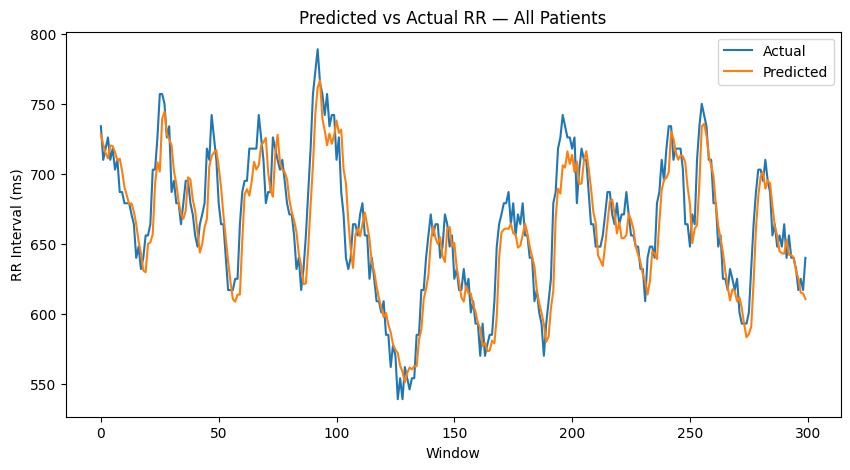

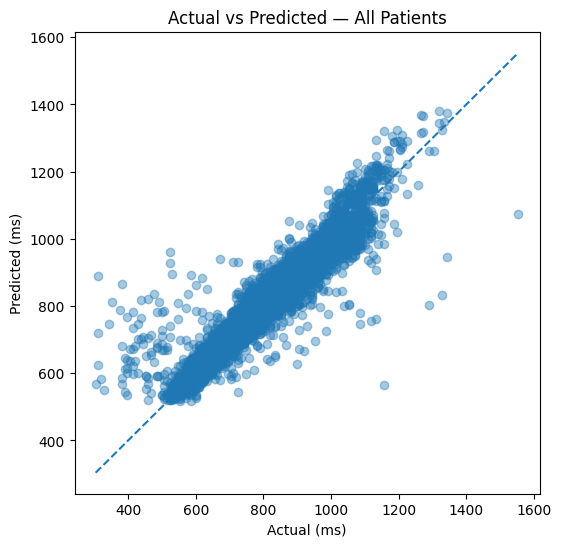

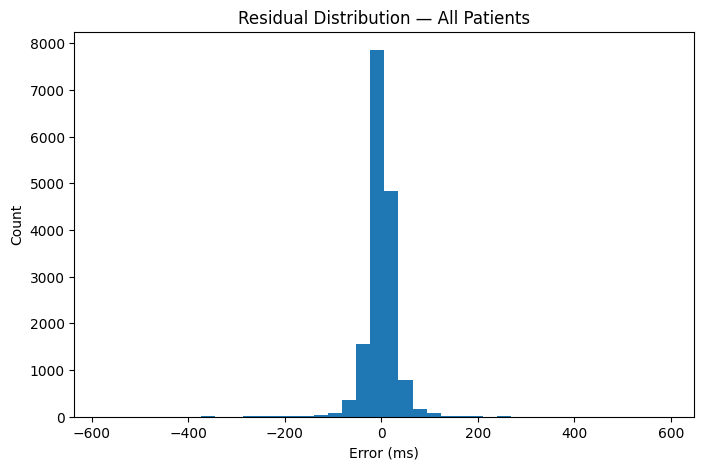

In [ ]:
import matplotlib.pyplot as plt

# Combine all patients
all_true = []
all_pred = []

for pid, res in all_patient_results.items():
    all_true.extend(res['y_true'][:300])
    all_pred.extend(res['y_pred'].flatten()[:300])

all_true = np.array(all_true)
all_pred = np.array(all_pred)

# Predicted vs Actual
plt.figure(figsize=(10, 5))
plt.plot(all_true[:300], label='Actual')
plt.plot(all_pred[:300], label='Predicted')
plt.legend()
plt.title('Predicted vs Actual RR — All Patients')
plt.xlabel('Window')
plt.ylabel('RR Interval (ms)')
plt.show()

# Scatter
plt.figure(figsize=(6, 6))
plt.scatter(all_true, all_pred, alpha=0.4)
plt.plot([min(all_true), max(all_true)],
         [min(all_true), max(all_true)], linestyle='--')
plt.title('Actual vs Predicted — All Patients')
plt.xlabel('Actual (ms)')
plt.ylabel('Predicted (ms)')
plt.show()

# Residuals
residuals = all_true - all_pred
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=40)
plt.title('Residual Distribution — All Patients')
plt.xlabel('Error (ms)')
plt.ylabel('Count')
plt.show()

This block visualizes the model's performance by combining the true and predicted RR interval values from all patients.  
1. **Predicted vs Actual:** It plots a time series comparison of actual vs. predicted RR intervals for the first 300 windows across all patients.  
2. **Scatter Plot:** It generates a scatter plot of actual vs. predicted values, including a diagonal line for perfect prediction, to visually assess correlation.  
3. **Residuals:** It creates a histogram of the prediction errors (residuals) to show their distribution, ideally centered around zero.

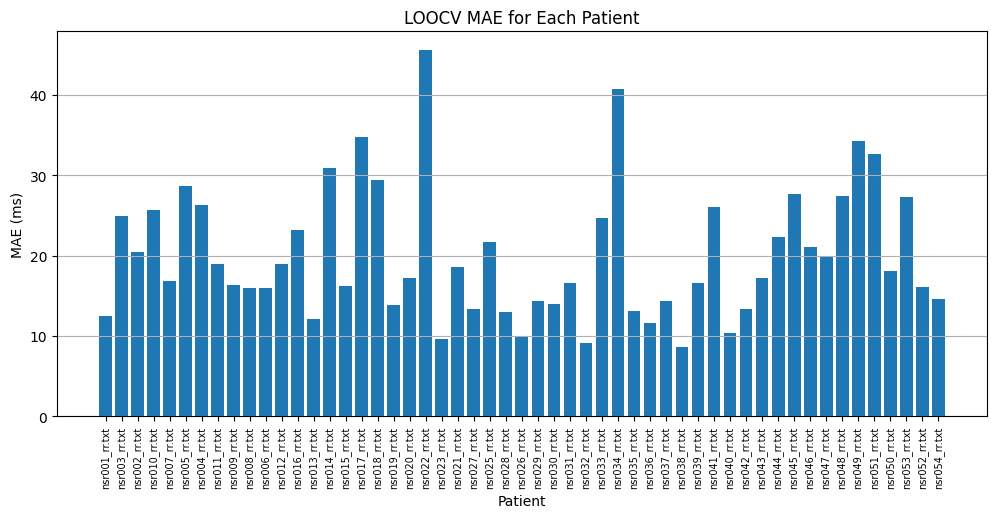

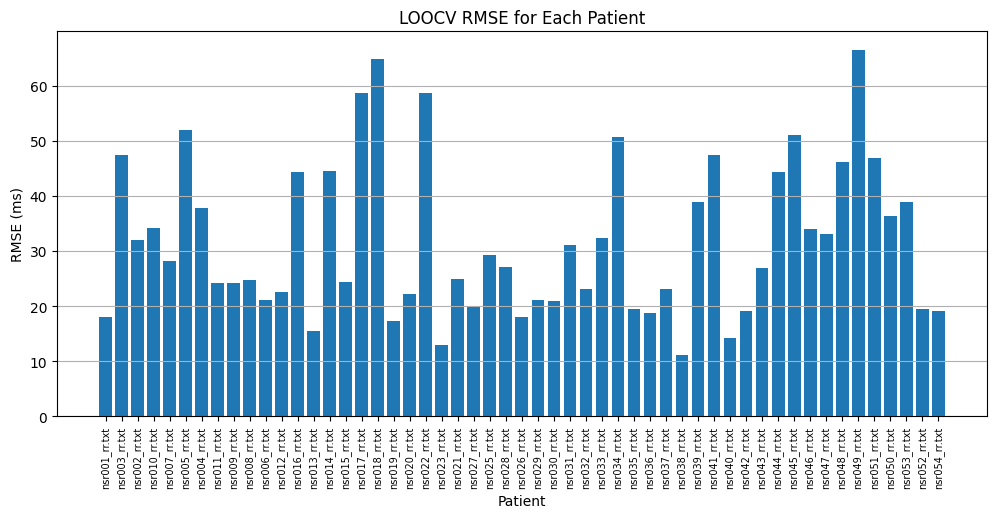

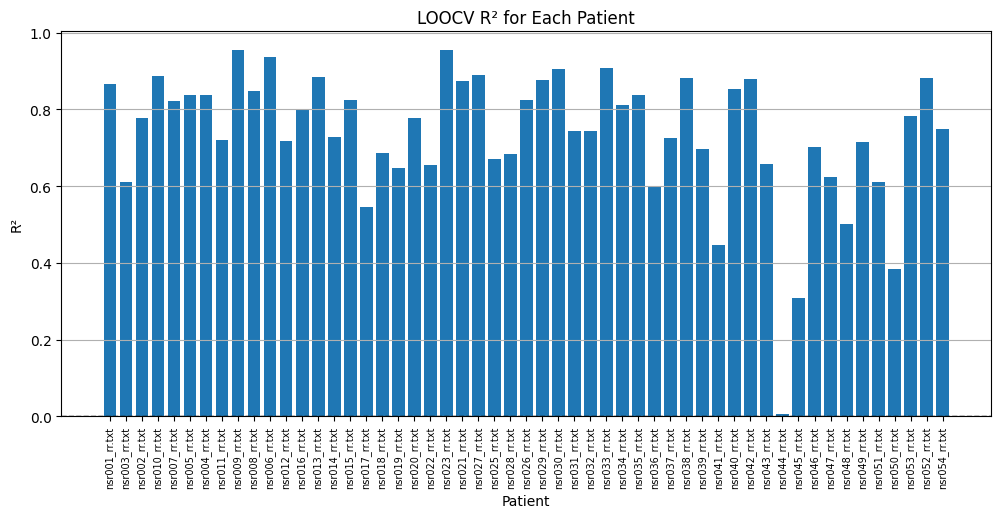

In [ ]:
patient_ids = list(all_patient_results.keys())
maes  = [mean_absolute_error(res['y_true'], res['y_pred']) for res in all_patient_results.values()]
rmses = [np.sqrt(mean_squared_error(res['y_true'], res['y_pred'])) for res in all_patient_results.values()]
r2s   = [r2_score(res['y_true'], res['y_pred']) for res in all_patient_results.values()]

plt.figure(figsize=(12, 5))
plt.bar(patient_ids, maes)
plt.xticks(rotation=90, fontsize=7)
plt.title("LOOCV MAE for Each Patient")
plt.xlabel("Patient")
plt.ylabel("MAE (ms)")
plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(patient_ids, rmses)
plt.xticks(rotation=90, fontsize=7)
plt.title("LOOCV RMSE for Each Patient")
plt.xlabel("Patient")
plt.ylabel("RMSE (ms)")
plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(patient_ids, r2s)
plt.xticks(rotation=90, fontsize=7)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title("LOOCV R² for Each Patient")
plt.xlabel("Patient")
plt.ylabel("R²")
plt.grid(True, axis="y")
plt.show()

This cell visualizes the performance metrics (MAE, RMSE, and R²) obtained from the LOOCV for each individual patient. It generates three bar plots: one for MAE, one for RMSE, and one for R², allowing for a clear comparison of how the model performed on different patients.

Changed the Epoch from 3 to 6 and took out patient 24


 K-Fold Validation


In [ ]:
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader

#Prepare data and group labels
X_list, y_list, groups_list = [], [], []

for pid, (X, y) in windows_per_patient.items():
    X_list.append(X)
    y_list.append(y)
    # Tag each window with its corresponding patient ID
    groups_list.extend([pid] * len(X))

X_all = np.concatenate(X_list, axis=0)
y_all = np.concatenate(y_list, axis=0)
groups_all = np.array(groups_list)

#Setup 5-Fold Group validation
n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

fold_metrics = []
print(f"Starting {n_splits}-Fold Group Cross-Validation...\n")

#Iterate through each fold
for fold, (train_idx, val_idx) in enumerate(gkf.split(X_all, y_all, groups=groups_all)):
    print(f"--- Fold {fold + 1}/{n_splits} ---")

    #Split data by the indices generated by GroupKFold
    X_train, y_train = X_all[train_idx], y_all[train_idx]
    X_val, y_val = X_all[val_idx], y_all[val_idx]

    #Subsample training data to maintain training speed
    MAX_TRAIN = 200_000
    if len(X_train) > MAX_TRAIN:
        rng = np.random.default_rng(seed=42)
        sub_idx = rng.choice(len(X_train), size=MAX_TRAIN, replace=False)
        X_train, y_train = X_train[sub_idx], y_train[sub_idx]

    #Scale data (fit ONLY on train to prevent data leakage)
    rr_mean = X_train.mean()
    rr_std  = X_train.std() + 1e-8

    X_train_scaled = (X_train - rr_mean) / rr_std
    X_val_scaled   = (X_val   - rr_mean) / rr_std
    y_train_scaled = (y_train - rr_mean) / rr_std
    y_val_scaled   = (y_val   - rr_mean) / rr_std

    #Create DataLoaders
    train_loader = DataLoader(RRWindowDataset(X_train_scaled, y_train_scaled), batch_size=256, shuffle=True)
    val_loader   = DataLoader(RRWindowDataset(X_val_scaled, y_val_scaled), batch_size=256, shuffle=False)

    #Initialize Model, Loss, and Optimizer for this fold
    model = RR_CNN().to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    #Train the model
    epochs = 6
    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

    #Evaluate the model on the unseen validation patients
    model.eval()
    with torch.no_grad():
        preds_scaled = model(torch.tensor(X_val_scaled, dtype=torch.float32).to(device)).cpu().numpy()

    #Inverse transform predictions and actuals back to milliseconds
    y_pred = preds_scaled * rr_std + rr_mean
    y_true = y_val_scaled * rr_std + rr_mean

    #Calculate Fold Metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    fold_metrics.append({'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f"Fold {fold + 1} Results -> MAE: {mae:.2f} ms | RMSE: {rmse:.2f} ms | R²: {r2:.3f}\n")

#Summary Statistics
avg_mae = np.mean([m['MAE'] for m in fold_metrics])
avg_rmse = np.mean([m['RMSE'] for m in fold_metrics])
avg_r2 = np.mean([m['R2'] for m in fold_metrics])

print("=== K-Fold Cross-Validation Summary ===")
print(f"Average MAE:  {avg_mae:.2f} ms")
print(f"Average RMSE: {avg_rmse:.2f} ms")
print(f"Average R²:   {avg_r2:.3f}")

Starting 5-Fold Group Cross-Validation...

--- Fold 1/5 ---
Fold 1 Results -> MAE: 20.40 ms | RMSE: 40.22 ms | R²: 0.915

--- Fold 2/5 ---
Fold 2 Results -> MAE: 19.78 ms | RMSE: 33.98 ms | R²: 0.953

--- Fold 3/5 ---
Fold 3 Results -> MAE: 15.54 ms | RMSE: 25.28 ms | R²: 0.922

--- Fold 4/5 ---
Fold 4 Results -> MAE: 20.74 ms | RMSE: 35.07 ms | R²: 0.910

--- Fold 5/5 ---
Fold 5 Results -> MAE: 20.48 ms | RMSE: 32.66 ms | R²: 0.922

=== K-Fold Cross-Validation Summary ===
Average MAE:  19.39 ms
Average RMSE: 33.44 ms
Average R²:   0.924


This cell implements a 5-Fold Group Cross-Validation. This method ensures that all data points from a single patient are kept together in either the training or validation set, preventing data leakage across folds.  
For each fold:  
1. It splits the data into training and validation sets based on patient groups.  
2. Subsamples the training data.  
3. Scales the data using only the training fold's statistics.  
4. Creates PyTorch `DataLoader`s.  
5. Initializes and trains a new `RR_CNN` model for 6 epochs.  
6. Evaluates the model on the validation fold, denormalizing predictions back to milliseconds.  
7. Calculates MAE, MSE, RMSE, and R² for the fold and stores them.  
Finally, it prints summary statistics (average MAE, RMSE, and R²) across all folds.

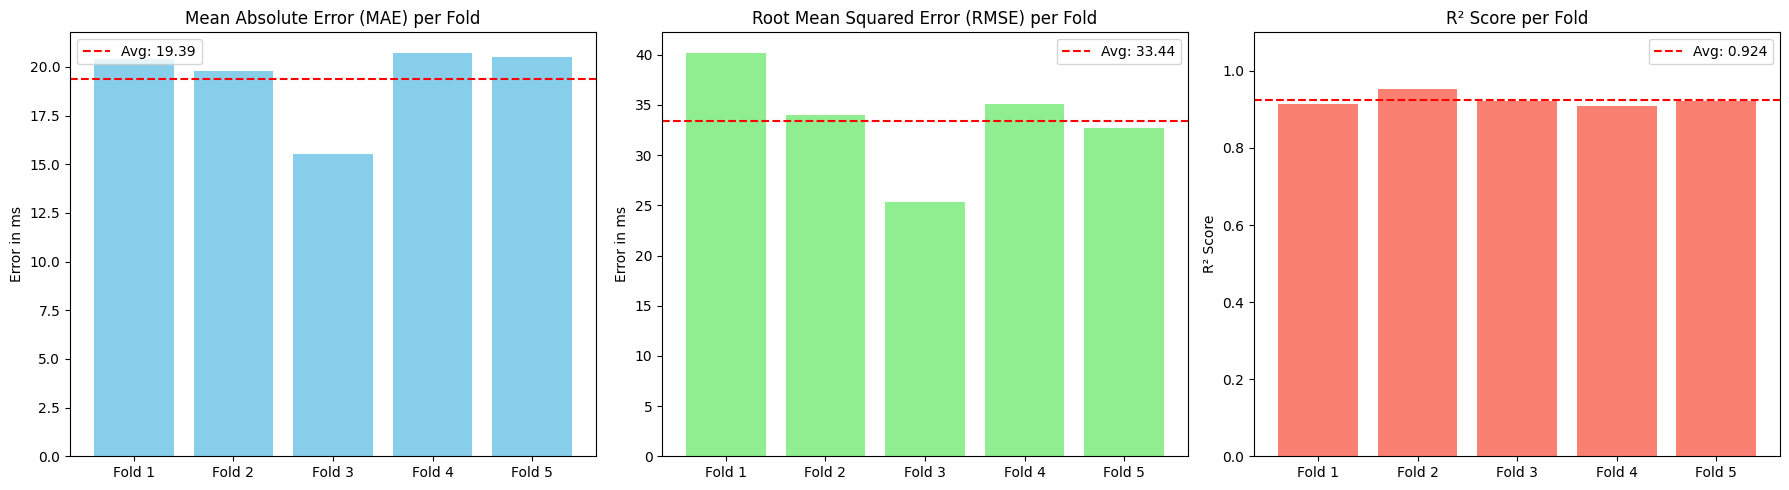

In [ ]:
# Extract metrics
folds = [f"Fold {i+1}" for i in range(len(fold_metrics))]
maes = [m['MAE'] for m in fold_metrics]
rmses = [m['RMSE'] for m in fold_metrics]
r2s = [m['R2'] for m in fold_metrics]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot MAE
axes[0].bar(folds, maes, color='skyblue')
axes[0].axhline(np.mean(maes), color='r', linestyle='--', label=f'Avg: {np.mean(maes):.2f}')
axes[0].set_title('Mean Absolute Error (MAE) per Fold')
axes[0].set_ylabel('Error in ms')
axes[0].legend()

# Plot RMSE
axes[1].bar(folds, rmses, color='lightgreen')
axes[1].axhline(np.mean(rmses), color='r', linestyle='--', label=f'Avg: {np.mean(rmses):.2f}')
axes[1].set_title('Root Mean Squared Error (RMSE) per Fold')
axes[1].set_ylabel('Error in ms')
axes[1].legend()

# Plot R²
axes[2].bar(folds, r2s, color='salmon')
axes[2].axhline(np.mean(r2s), color='r', linestyle='--', label=f'Avg: {np.mean(r2s):.3f}')
axes[2].set_title('R² Score per Fold')
axes[2].set_ylabel('R² Score')
axes[2].set_ylim(0, 1.1)
axes[2].legend()

plt.tight_layout()
plt.show()

This code block visualizes the results of the K-Fold Group Cross-Validation. It generates three bar charts showing the MAE, RMSE, and R² scores for each of the 5 folds. A horizontal line indicates the average metric value across all folds, providing a clear summary of the model's performance consistency.

In [ ]:
#Ensure we are using the A100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ({torch.cuda.get_device_name(0)})")

#1. Setup Advanced Parameters
n_inner_folds=3
# Expanded grid for "top-notch" search
hyperparam_grid = {'lr': [1e-3, 5e-4, 1e-4]}
epochs_search = 5   # Quick epochs to find the best learning rate
epochs_final = 30   # More epochs for the final evaluation on the test patient
batch_size = 1024   # Large batch size for A100 speed

nested_cv_results = {}
patient_ids = list(clean_windows.keys())

#2. Outer Loop: Leave-One-Out Cross-Validation
for test_patient in patient_ids:
    print(f"\n{"="*30}")
    print(f"OUTER LOOCV: Testing on Held-out Patient {test_patient}")
    print(f"{"="*30}")

    # A. Split into Training Pool vs. Single Test Patient
    X_train_pool_list, y_train_pool_list, groups_train_pool_list = [], [], []

    for pid, (X, y) in clean_windows.items():
        if pid == test_patient:
            X_test_final, y_test_final = X, y
        else:
            X_train_pool_list.append(X)
            y_train_pool_list.append(y)
            groups_train_pool_list.extend([pid] * len(X))

    X_train_pool = np.concatenate(X_train_pool_list, axis=0)
    y_train_pool = np.concatenate(y_train_pool_list, axis=0)
    groups_train_pool = np.array(groups_train_pool_list)

    #B. Inner Loop: Hyperparameter Selection (GroupKFold)
    best_lr = None
    best_inner_mae = float('inf')

    for lr_candidate in hyperparam_grid['lr']:
        print(f"  > Searching Inner Loop: Testing LR = {lr_candidate}")
        gkf = GroupKFold(n_splits=n_inner_folds)
        inner_fold_maes = []

        for fold, (in_idx, val_idx) in enumerate(gkf.split(X_train_pool, y_train_pool, groups=groups_train_pool)):
            # Split
            X_in, y_in = X_train_pool[in_idx], y_train_pool[in_idx]
            X_val, y_val = X_train_pool[val_idx], y_train_pool[val_idx]

            # Scale (Fit on X_in, apply to X_val)
            mu, sigma = X_in.mean(), X_in.std() + 1e-8
            X_in_sc, y_in_sc = (X_in - mu) / sigma, (y_in - mu) / sigma
            X_val_sc, y_val_sc = (X_val - mu) / sigma, (y_val - mu) / sigma

            # Train Candidate Model
            train_loader = DataLoader(RRWindowDataset(X_in_sc, y_in_sc), batch_size=batch_size, shuffle=True)
            candidate_model = RR_CNN().to(device)
            opt = torch.optim.Adam(candidate_model.parameters(), lr=lr_candidate)
            crit = nn.MSELoss()

            candidate_model.train()
            for _ in range(epochs_search):
                for xb, yb in train_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    opt.zero_grad()
                    crit(candidate_model(xb), yb).backward()
                    opt.step()

            # Evaluate Candidate on Inner Validation Fold
            candidate_model.eval()
            with torch.no_grad():
                val_preds_sc = candidate_model(torch.tensor(X_val_sc, dtype=torch.float32).to(device)).cpu().numpy()

            # Rescale back to ms for error calculation
            y_pred_ms = val_preds_sc * sigma + mu
            y_true_ms = y_val_sc * sigma + mu
            inner_fold_maes.append(mean_absolute_error(y_true_ms, y_pred_ms))

        avg_inner_mae = np.mean(inner_fold_maes)
        print(f"    - Avg Inner MAE for LR {lr_candidate}: {avg_inner_mae:.2f} ms")

        if avg_inner_mae < best_inner_mae:
            best_inner_mae = avg_inner_mae
            best_lr = lr_candidate

    print(f"  [*] WINNER: Best LR for this patient is {best_lr}")

    #C. Final Evaluation: Test the winner on the Held-out Patient ---
    print(f"  [!] Training Final Model for evaluation on {test_patient}...")

    # Scale using the ENTIRE training pool
    mu_final, sigma_final = X_train_pool.mean(), X_train_pool.std() + 1e-8
    X_train_all_sc = (X_train_pool - mu_final) / sigma_final
    y_train_all_sc = (y_train_pool - mu_final) / sigma_final
    X_test_sc = (X_test_final - mu_final) / sigma_final

    final_loader = DataLoader(RRWindowDataset(X_train_all_sc, y_train_all_sc), batch_size=batch_size, shuffle=True)
    final_model = RR_CNN().to(device)
    final_opt = torch.optim.Adam(final_model.parameters(), lr=best_lr)

    # Full training for final assessment
    final_model.train()
    for ep in range(epochs_final):
        for xb, yb in final_loader:
            xb, yb = xb.to(device), yb.to(device)
            final_opt.zero_grad()
            crit(final_model(xb), yb).backward()
            final_opt.step()

    # Evaluate on the Held-out Test Patient
    final_model.eval()
    with torch.no_grad():
        test_preds_sc = final_model(torch.tensor(X_test_sc, dtype=torch.float32).to(device)).cpu().numpy()

    y_test_pred_ms = test_preds_sc * sigma_final + mu_final
    y_test_true_ms = y_test_final # Already in ms

    # Calculate Assessment Metrics
    final_mae = mean_absolute_error(y_test_true_ms, y_test_pred_ms)
    final_mse = mean_squared_error(y_test_true_ms, y_test_pred_ms)
    final_r2 = r2_score(y_test_true_ms, y_test_pred_ms)

    print(f"  [RESULT] Held-out MAE: {final_mae:.2f} ms | R2: {final_r2:.4f}")

    nested_cv_results[test_patient] = {
        'best_lr': best_lr,
        'mae': final_mae,
        'mse': final_mse,
        'r2': final_r2
    }

# --- 3. Final Aggregated Results ---
all_maes = [res['mae'] for res in nested_cv_results.values()]
print(f"\n\nFINAL NESTED CV MAE: {np.mean(all_maes):.2f} ± {np.std(all_maes):.2f} ms")

Using device: cuda (NVIDIA A100-SXM4-40GB)

OUTER LOOCV: Testing on Held-out Patient nsr001_rr.txt
  > Searching Inner Loop: Testing LR = 0.001
    - Avg Inner MAE for LR 0.001: 21.02 ms
  > Searching Inner Loop: Testing LR = 0.0005
    - Avg Inner MAE for LR 0.0005: 21.79 ms
  > Searching Inner Loop: Testing LR = 0.0001
    - Avg Inner MAE for LR 0.0001: 22.00 ms
  [*] WINNER: Best LR for this patient is 0.001
  [!] Training Final Model for evaluation on nsr001_rr.txt...
  [RESULT] Held-out MAE: 15.24 ms | R2: 0.8313

OUTER LOOCV: Testing on Held-out Patient nsr003_rr.txt
  > Searching Inner Loop: Testing LR = 0.001
    - Avg Inner MAE for LR 0.001: 20.16 ms
  > Searching Inner Loop: Testing LR = 0.0005
    - Avg Inner MAE for LR 0.0005: 19.55 ms
  > Searching Inner Loop: Testing LR = 0.0001
    - Avg Inner MAE for LR 0.0001: 21.36 ms
  [*] WINNER: Best LR for this patient is 0.0005
  [!] Training Final Model for evaluation on nsr003_rr.txt...
  [RESULT] Held-out MAE: 25.16 ms | R2: 0

This advanced block implements nested cross-validation to find the best hyperparameters (specifically, the learning rate `lr`) while rigorously evaluating the model's generalization performance.  

**Outer Loop (LOOCV):** It holds out one patient for final testing.  

**Inner Loop (GroupKFold):** From the remaining patients, it performs a 3-Fold Group Cross-Validation to search for the best learning rate by training candidate models for `epochs_search` (5 epochs).  

**Final Evaluation:** Once the best `lr` is found, a final model is trained on *all* non-held-out patients using this best `lr` for `epochs_final` (30 epochs). This final model is then evaluated on the completely unseen held-out patient.  

The process repeats for each patient as the held-out test patient, providing robust metrics (`mae`, `mse`, `r2`) and the best learning rate for each patient. Finally, it prints the aggregated mean and standard deviation of MAE across all outer LOOCV folds.